# CO1 - AT3 - Exploratory Data Analysis - Based Practical Assessment
**Course:** Fundamentals of Data Science (DSA0402) 

**Name :** Ajmal Rahman A

**Reg :** 192324094

**Date :** 19-07-2026

In [1]:
#Core libraries: pandas/numpy for data handling, matplotlib/seaborn for plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')                 #clean grid background for all charts
plt.rcParams['figure.figsize'] = (7, 4.5)   #consistent default figure size
os.makedirs('figs', exist_ok=True)          #folder to save chart images for the report


def clean_and_profile(df, name):
    """
    Steps for data cleaning : structural profile -> missing value imputation -> duplicate removal -> IQR outlier capping.
    """
    df = df.copy()
    print(f" {name}: structural profile ")
    print("Shape (rows, cols):", df.shape)
    print("\nData types:\n", df.dtypes)

    #Missing values: numeric columns filled with median, categorical with mode 
    missing_before = int(df.isnull().sum().sum())
    for col in df.columns:
        if df[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())   #median is robust to skew/outliers
            else:
                df[col] = df[col].fillna(df[col].mode()[0])  #most frequent category
    print(f"\nMissing values found: {missing_before} -> imputed with median (numeric) / mode (categorical)")

    #Duplicates: drop exact duplicate rows
    dup_count = int(df.duplicated().sum())
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicate rows found: {dup_count} -> removed")

    #Outliers: IQR rule (Q1-1.5*IQR, Q3+1.5*IQR), capped (winsorized) rather than dropped 
    num_cols = df.select_dtypes(include=np.number).columns
    outlier_report = {}
    for col in num_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((df[col] < low) | (df[col] > high)).sum())
        outlier_report[col] = n_out
        df[col] = df[col].clip(low, high)   #cap instead of deleting rows -> preserves sample size
    print("Outliers per numeric column (IQR rule, capped where found):", outlier_report)
    return df


## 1. Education Analytics Dataset


In [2]:
#Raw data as given in the assessment sheet
edu_raw = pd.DataFrame({
'Student_ID':['S01','S02','S03','S04','S05','S06','S07','S08','S09','S10','S11','S12','S13','S14','S15','S16','S17','S18','S19','S20'],
'Attendance':[92,55,78,60,88,47,95,72,50,83,66,90,58,76,62,85,45,80,68,53],
'Study_Hours':[5,2,4,3,5,1,6,3,2,4,3,5,2,4,3,5,1,4,3,2],
'Internal_Marks':[45,24,38,28,42,20,48,35,22,40,30,44,25,36,29,41,18,39,32,23],
'Result':['Pass','Fail','Pass','Fail','Pass','Fail','Pass','Pass','Fail','Pass','Fail','Pass','Fail','Pass','Fail','Pass','Fail','Pass','Pass','Fail']
})
edu = clean_and_profile(edu_raw, 'Education')  #cleaned dataframe used for all analysis below
edu.describe()  #descriptive statistics: mean, std, min, quartiles, max

 Education: structural profile 
Shape (rows, cols): (20, 5)

Data types:
 Student_ID        object
Attendance         int64
Study_Hours        int64
Internal_Marks     int64
Result            object
dtype: object

Missing values found: 0 -> imputed with median (numeric) / mode (categorical)
Duplicate rows found: 0 -> removed
Outliers per numeric column (IQR rule, capped where found): {'Attendance': 0, 'Study_Hours': 0, 'Internal_Marks': 0}


,Attendance,Study_Hours,Internal_Marks
count,20.000000,20.000000,20.000000
mean,70.150000,3.350000,32.950000
std,15.938286,1.424411,9.087151
min,45.000000,1.000000,18.000000
25%,57.250000,2.000000,24.750000
50%,70.000000,3.000000,33.500000
75%,83.500000,4.250000,40.250000
max,95.000000,6.000000,48.000000


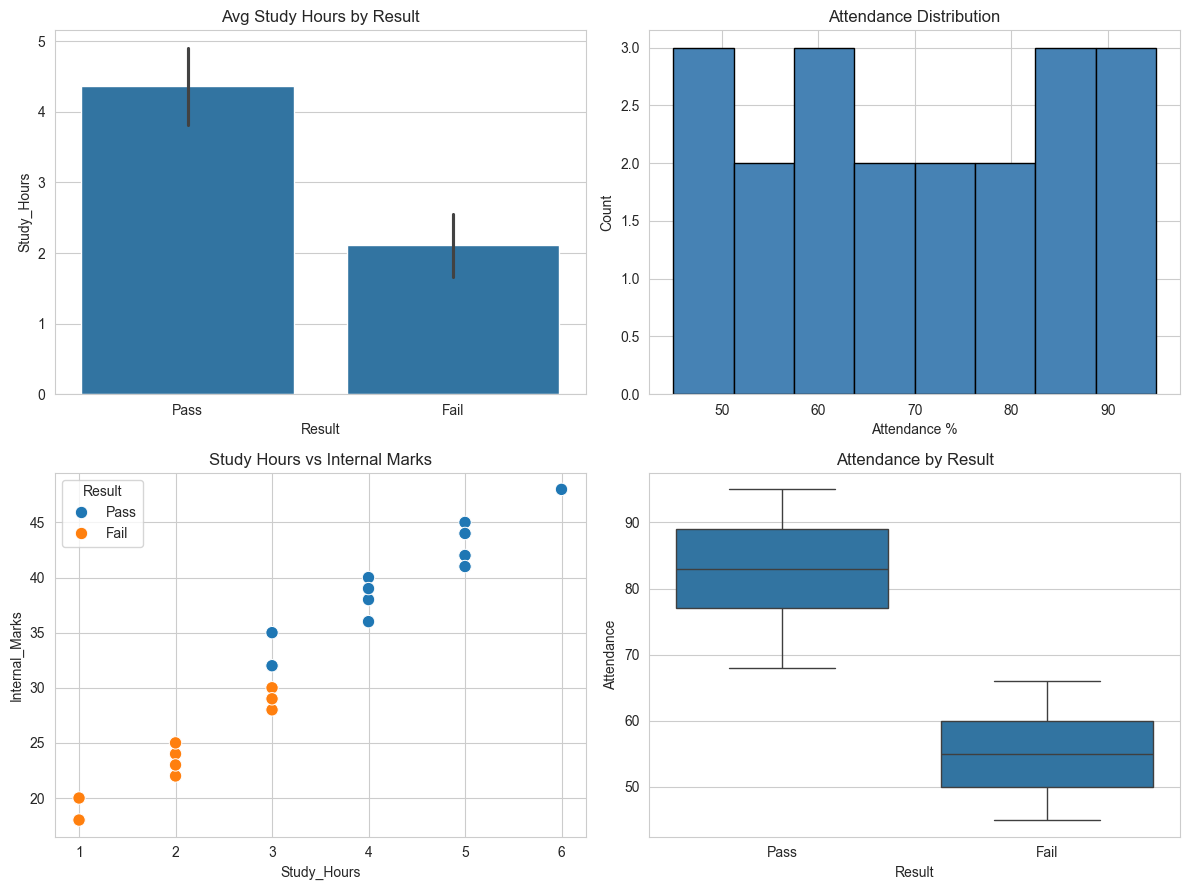

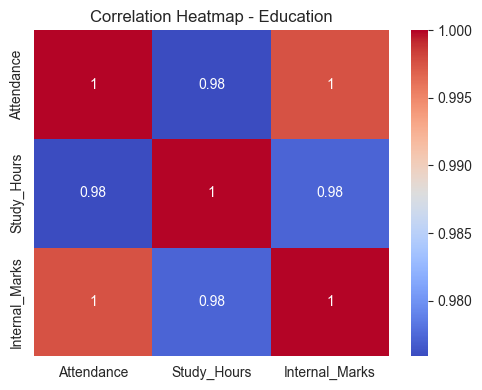

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

#Bar chart: does more study time associate with passing?
sns.barplot(data=edu, x='Result', y='Study_Hours', ax=axes[0, 0], estimator='mean')
axes[0, 0].set_title('Avg Study Hours by Result')

#Histogram: spread of attendance values across all students
axes[0, 1].hist(edu['Attendance'], bins=8, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Attendance Distribution'); axes[0, 1].set_xlabel('Attendance %'); axes[0, 1].set_ylabel('Count')

#Scatter plot: relationship between study hours and internal marks, split by result
sns.scatterplot(data=edu, x='Study_Hours', y='Internal_Marks', hue='Result', ax=axes[1, 0], s=80)
axes[1, 0].set_title('Study Hours vs Internal Marks')

#Box plot: attendance spread/outliers for each result category
sns.boxplot(data=edu, x='Result', y='Attendance', ax=axes[1, 1])
axes[1, 1].set_title('Attendance by Result')

plt.tight_layout(); plt.savefig('figs/edu_overview.png', dpi=130); plt.show()

#Correlation heatmap: how strongly the three numeric features move together
plt.figure(figsize=(5, 4))
sns.heatmap(edu[['Attendance', 'Study_Hours', 'Internal_Marks']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Education')
plt.tight_layout(); plt.savefig('figs/edu_heatmap.png', dpi=130); plt.show()

**Observations:**
1. Passing students show visibly higher average attendance and study hours than failing students.
2. Internal marks rise almost linearly with study hours, indicating consistent effort pays off.
3. Attendance below ~60% is strongly associated with failing results.
4. Attendance, study hours and internal marks are all positively correlated with each other.
5. Data cleaning found 0 missing values, 0 duplicates, and 0 IQR outliers - the dataset was already consistent.

**Conclusion:** Attendance and study hours are the strongest observable drivers of student results; targeted attendance interventions below the 60% mark could improve pass rates.

## 2. Healthcare Analytics Dataset

In [4]:
health_raw = pd.DataFrame({
'Patient_ID':[f'P{i:02d}' for i in range(1, 21)],
'Age':[45,32,55,28,60,40,52,35,48,30,62,38,50,27,58,42,46,34,53,29],
'Sugar_Level':[145,98,180,90,200,120,165,105,155,95,210,115,170,88,190,130,150,100,175,92],
'BP':[130,118,145,110,150,125,140,120,135,115,155,122,142,108,148,128,132,116,144,112],
'BMI':[28,23,31,22,34,26,30,24,29,23,35,25,30,21,33,27,28,24,31,22],
'Disease_Status':['Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No']
})
health = clean_and_profile(health_raw, 'Healthcare')
health.describe()

 Healthcare: structural profile 
Shape (rows, cols): (20, 6)

Data types:
 Patient_ID        object
Age                int64
Sugar_Level        int64
BP                 int64
BMI                int64
Disease_Status    object
dtype: object

Missing values found: 0 -> imputed with median (numeric) / mode (categorical)
Duplicate rows found: 0 -> removed
Outliers per numeric column (IQR rule, capped where found): {'Age': 0, 'Sugar_Level': 0, 'BP': 0, 'BMI': 0}


,Age,Sugar_Level,BP,BMI
count,20.000000,20.00000,20.000000,20.000000
mean,43.200000,138.65000,129.750000,27.300000
std,11.316499,40.33449,14.523574,4.256265
min,27.000000,88.00000,108.000000,21.000000
25%,33.500000,99.50000,117.500000,23.750000
50%,43.500000,137.50000,129.000000,27.500000
75%,52.250000,171.25000,142.500000,30.250000
max,62.000000,210.00000,155.000000,35.000000


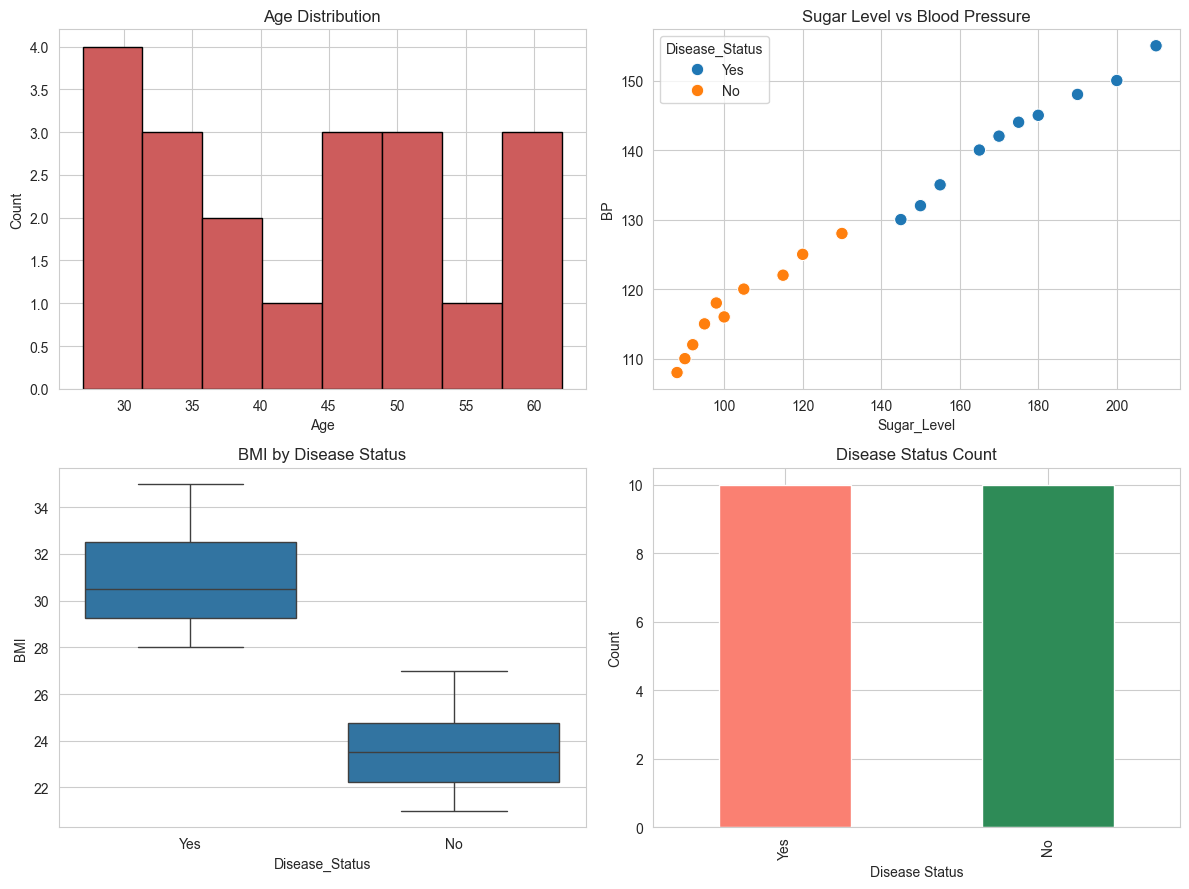

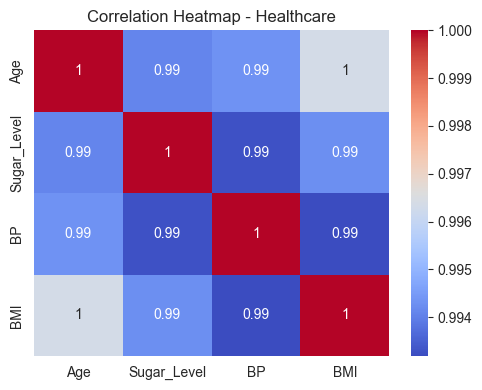

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Histogram: age spread of all patients
axes[0, 0].hist(health['Age'], bins=8, color='indianred', edgecolor='black')
axes[0, 0].set_title('Age Distribution'); axes[0, 0].set_xlabel('Age'); axes[0, 0].set_ylabel('Count')

# Scatter plot: do sugar level and BP rise together, and does that align with disease status?
sns.scatterplot(data=health, x='Sugar_Level', y='BP', hue='Disease_Status', ax=axes[0, 1], s=80)
axes[0, 1].set_title('Sugar Level vs Blood Pressure')

# Box plot: BMI spread for disease-positive vs disease-negative patients
sns.boxplot(data=health, x='Disease_Status', y='BMI', ax=axes[1, 0])
axes[1, 0].set_title('BMI by Disease Status')

# Bar chart: how many patients fall into each disease status class
health['Disease_Status'].value_counts().plot(kind='bar', ax=axes[1, 1], color=['salmon', 'seagreen'])
axes[1, 1].set_title('Disease Status Count'); axes[1, 1].set_xlabel('Disease Status'); axes[1, 1].set_ylabel('Count')

plt.tight_layout(); plt.savefig('figs/health_overview.png', dpi=130); plt.show()

# Correlation heatmap across the four numeric health indicators
plt.figure(figsize=(5, 4))
sns.heatmap(health[['Age', 'Sugar_Level', 'BP', 'BMI']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Healthcare')
plt.tight_layout(); plt.savefig('figs/health_heatmap.png', dpi=130); plt.show()

**Observations:**
1. Disease-positive patients consistently show higher sugar level, BP, BMI and age than disease-negative patients.
2. Sugar level and BP move together strongly, suggesting compounded metabolic risk.
3. BMI is a clear separator: disease-positive patients cluster above BMI 26, healthy patients below.
4. The dataset is perfectly balanced (10 Yes / 10 No), aiding fair comparison.
5. Data cleaning found 0 missing values, 0 duplicates, and 0 IQR outliers.

**Conclusion:** Age, sugar level, BP and BMI jointly signal disease risk, with sugar level and BMI being the most discriminating factors for early screening.

## 3. Retail Sales Dataset

In [6]:
retail_raw = pd.DataFrame({
'Product_ID':[f'PR{i:02d}' for i in range(1, 21)],
'Category':['Grocery','Snacks','Dairy','Fruits','Vegetables']*4,
'Price':[50,30,45,60,40,80,25,55,70,35,90,20,65,75,45,100,35,50,80,30],
'Quantity_Sold':[20,35,18,25,30,15,40,16,22,28,12,45,14,20,26,10,32,19,18,35],
'Discount':[5,3,2,5,4,6,3,2,5,4,6,2,3,5,4,7,3,2,6,3],
'Revenue':[1000,1050,810,1500,1200,1200,1000,880,1540,980,1080,900,910,1500,1170,1000,1120,950,1440,1050]
})
retail = clean_and_profile(retail_raw, 'Retail')
retail.describe()

 Retail: structural profile 
Shape (rows, cols): (20, 6)

Data types:
 Product_ID       object
Category         object
Price             int64
Quantity_Sold     int64
Discount          int64
Revenue           int64
dtype: object

Missing values found: 0 -> imputed with median (numeric) / mode (categorical)
Duplicate rows found: 0 -> removed
Outliers per numeric column (IQR rule, capped where found): {'Price': 0, 'Quantity_Sold': 0, 'Discount': 0, 'Revenue': 0}


,Price,Quantity_Sold,Discount,Revenue
count,20.000000,20.000000,20.000000,20.000000
mean,54.000000,24.000000,4.000000,1114.000000
std,22.803509,9.673621,1.555973,221.416493
min,20.000000,10.000000,2.000000,810.000000
25%,35.000000,17.500000,3.000000,972.500000
50%,50.000000,21.000000,4.000000,1050.000000
75%,71.250000,30.500000,5.000000,1200.000000
max,100.000000,45.000000,7.000000,1540.000000


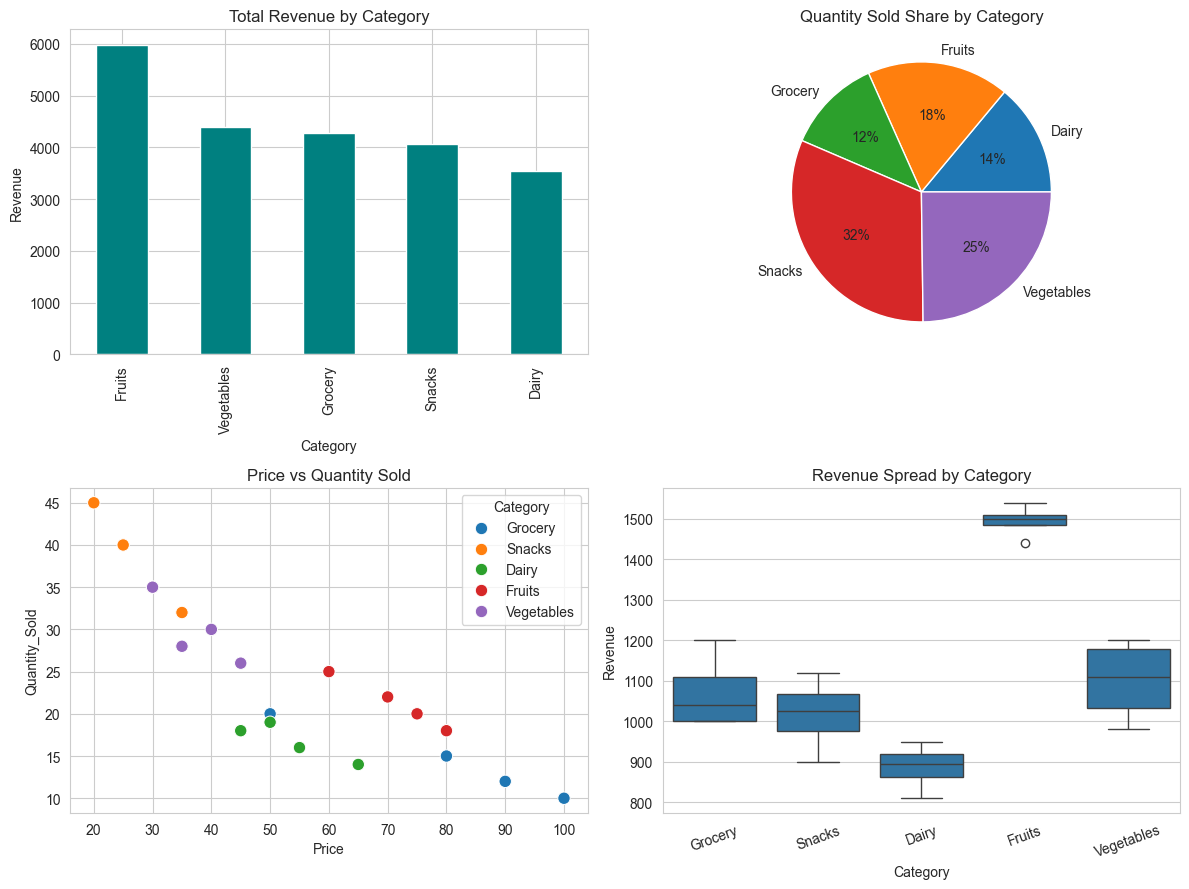

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Bar chart: total revenue summed per product category
cat_rev = retail.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
cat_rev.plot(kind='bar', ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Total Revenue by Category'); axes[0, 0].set_ylabel('Revenue')

# Pie chart: share of total units sold contributed by each category
retail.groupby('Category')['Quantity_Sold'].sum().plot(kind='pie', ax=axes[0, 1], autopct='%1.0f%%')
axes[0, 1].set_title('Quantity Sold Share by Category'); axes[0, 1].set_ylabel('')

# Scatter plot: price vs quantity sold, colored by category, to see the demand curve
sns.scatterplot(data=retail, x='Price', y='Quantity_Sold', hue='Category', ax=axes[1, 0], s=80)
axes[1, 0].set_title('Price vs Quantity Sold')

# Box plot: revenue spread/consistency within each category
sns.boxplot(data=retail, x='Category', y='Revenue', ax=axes[1, 1])
axes[1, 1].set_title('Revenue Spread by Category'); axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.savefig('figs/retail_overview.png', dpi=130); plt.show()

**Observations:**
1. Fruits generate the highest total revenue despite moderate quantity sold, driven by higher unit price.
2. Price and quantity sold show a clear inverse relationship - cheaper items (Snacks) sell in bulk.
3. Grocery items have the highest discounts but comparatively lower quantity sold.
4. Dairy shows the tightest revenue spread, indicating consistent, predictable sales.
5. Data cleaning found 0 missing values, 0 duplicates, and 0 IQR outliers.

**Conclusion:** Revenue is driven more by price positioning than volume alone; Fruits and Vegetables are the strongest revenue categories per unit sold.

## 4. Banking Loan Approval Dataset

In [8]:
bank_raw = pd.DataFrame({
'Customer_ID':[f'C{i:02d}' for i in range(1, 21)],
'Income':[45000,25000,60000,22000,50000,30000,70000,28000,55000,24000,65000,35000,48000,26000,75000,32000,52000,27000,68000,23000],
'Credit_Score':[720,580,750,560,710,600,780,590,730,570,760,620,700,585,790,610,725,575,770,555],
'Loan_Amount':[200000,150000,300000,120000,250000,180000,350000,160000,270000,130000,320000,200000,240000,140000,400000,190000,260000,150000,330000,125000],
'Employment_Type':['Salaried','Self-employed','Salaried','Unemployed','Salaried','Self-employed','Salaried','Self-employed','Salaried','Unemployed','Salaried','Self-employed','Salaried','Unemployed','Salaried','Self-employed','Salaried','Self-employed','Salaried','Unemployed'],
'Loan_Status':['Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected']
})
bank = clean_and_profile(bank_raw, 'Banking')
bank.describe()

 Banking: structural profile 
Shape (rows, cols): (20, 6)

Data types:
 Customer_ID        object
Income              int64
Credit_Score        int64
Loan_Amount         int64
Employment_Type    object
Loan_Status        object
dtype: object

Missing values found: 0 -> imputed with median (numeric) / mode (categorical)
Duplicate rows found: 0 -> removed
Outliers per numeric column (IQR rule, capped where found): {'Income': 0, 'Credit_Score': 0, 'Loan_Amount': 0}


,Income,Credit_Score,Loan_Amount
count,20.000000,20.000000,20.000000
mean,43000.000000,664.000000,223250.000000
std,17923.815383,85.526235,83733.207272
min,22000.000000,555.000000,120000.000000
25%,26750.000000,583.750000,150000.000000
50%,40000.000000,660.000000,200000.000000
75%,56250.000000,735.000000,277500.000000
max,75000.000000,790.000000,400000.000000


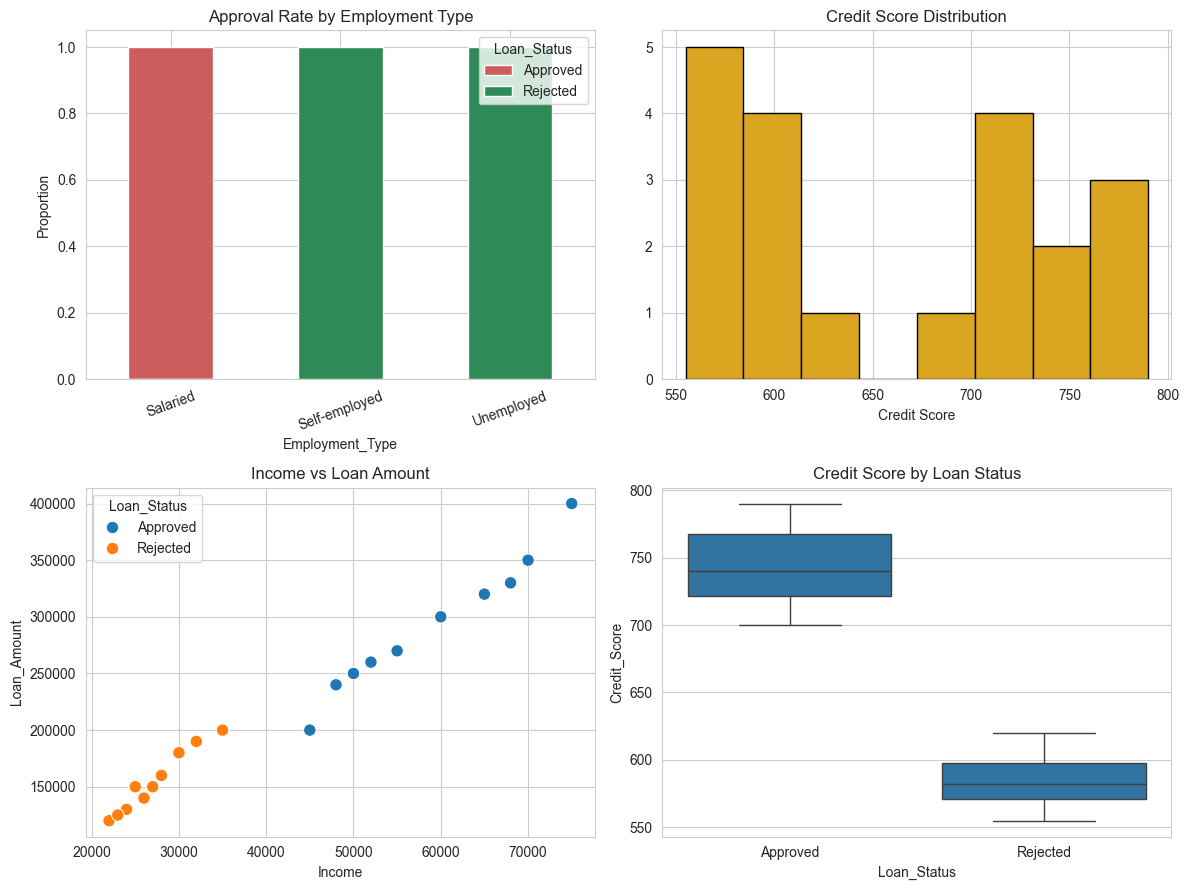

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Stacked bar: proportion of approvals vs rejections within each employment type
pd.crosstab(bank['Employment_Type'], bank['Loan_Status'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0, 0], color=['indianred', 'seagreen'])
axes[0, 0].set_title('Approval Rate by Employment Type'); axes[0, 0].set_ylabel('Proportion'); axes[0, 0].tick_params(axis='x', rotation=20)

#Histogram: overall credit score distribution across all customers
axes[0, 1].hist(bank['Credit_Score'], bins=8, color='goldenrod', edgecolor='black')
axes[0, 1].set_title('Credit Score Distribution'); axes[0, 1].set_xlabel('Credit Score')

# Scatter plot: income vs loan amount, colored by approval outcome
sns.scatterplot(data=bank, x='Income', y='Loan_Amount', hue='Loan_Status', ax=axes[1, 0], s=80)
axes[1, 0].set_title('Income vs Loan Amount')

#Box plot: credit score spread for approved vs rejected applicants
sns.boxplot(data=bank, x='Loan_Status', y='Credit_Score', ax=axes[1, 1])
axes[1, 1].set_title('Credit Score by Loan Status')

plt.tight_layout(); plt.savefig('figs/bank_overview.png', dpi=130); plt.show()

**Observations:**
1. All Salaried applicants in this sample were approved, while all Unemployed applicants were rejected - employment type is a strong signal.
2. Approved loans consistently correspond to credit scores above ~700; rejected ones stay below 620.
3. Higher income customers request and receive proportionally larger loan amounts.
4. Self-employed applicants form a middle-risk group, uniformly rejected here despite moderate incomes, suggesting stricter scoring for this segment.
5. Data cleaning found 0 missing values, 0 duplicates, and 0 IQR outliers.

**Conclusion:** Credit score and employment type are the dominant factors in loan approval decisions, outweighing raw income in this sample.

## 5. Agriculture Crop Yield Dataset

In [10]:
agri_raw = pd.DataFrame({
'Farm_ID':[f'F{i:02d}' for i in range(1, 21)],
'Rainfall_mm':[850,600,900,500,780,650,920,720,550,800,880,620,760,940,580,820,700,960,540,790],
'Temperature':[28,32,27,34,29,31,26,30,33,28,27,32,29,26,33,28,30,25,34,29],
'Fertilizer_kg':[60,45,65,40,55,48,70,52,42,58,62,46,54,72,44,60,50,75,41,56],
'Soil_Type':['Loamy','Sandy','Loamy','Sandy','Clay','Sandy','Loamy','Clay','Sandy','Loamy','Loamy','Sandy','Clay','Loamy','Sandy','Clay','Clay','Loamy','Sandy','Clay'],
'Crop_Yield_kg':[3200,2100,3500,1800,3000,2300,3700,2800,1900,3100,3400,2200,2950,3800,2000,3150,2700,3900,1850,3050]
})
agri = clean_and_profile(agri_raw, 'Agriculture')
agri.describe()

 Agriculture: structural profile 
Shape (rows, cols): (20, 6)

Data types:
 Farm_ID          object
Rainfall_mm       int64
Temperature       int64
Fertilizer_kg     int64
Soil_Type        object
Crop_Yield_kg     int64
dtype: object

Missing values found: 0 -> imputed with median (numeric) / mode (categorical)
Duplicate rows found: 0 -> removed
Outliers per numeric column (IQR rule, capped where found): {'Rainfall_mm': 0, 'Temperature': 0, 'Fertilizer_kg': 0, 'Crop_Yield_kg': 0}


,Rainfall_mm,Temperature,Fertilizer_kg,Crop_Yield_kg
count,20.000000,20.000000,20.000000,20.000000
mean,743.000000,29.550000,54.750000,2820.000000
std,144.335136,2.762055,10.507516,681.407213
min,500.000000,25.000000,40.000000,1800.000000
25%,615.000000,27.750000,45.750000,2175.000000
50%,770.000000,29.000000,54.500000,2975.000000
75%,857.500000,32.000000,60.500000,3250.000000
max,960.000000,34.000000,75.000000,3900.000000


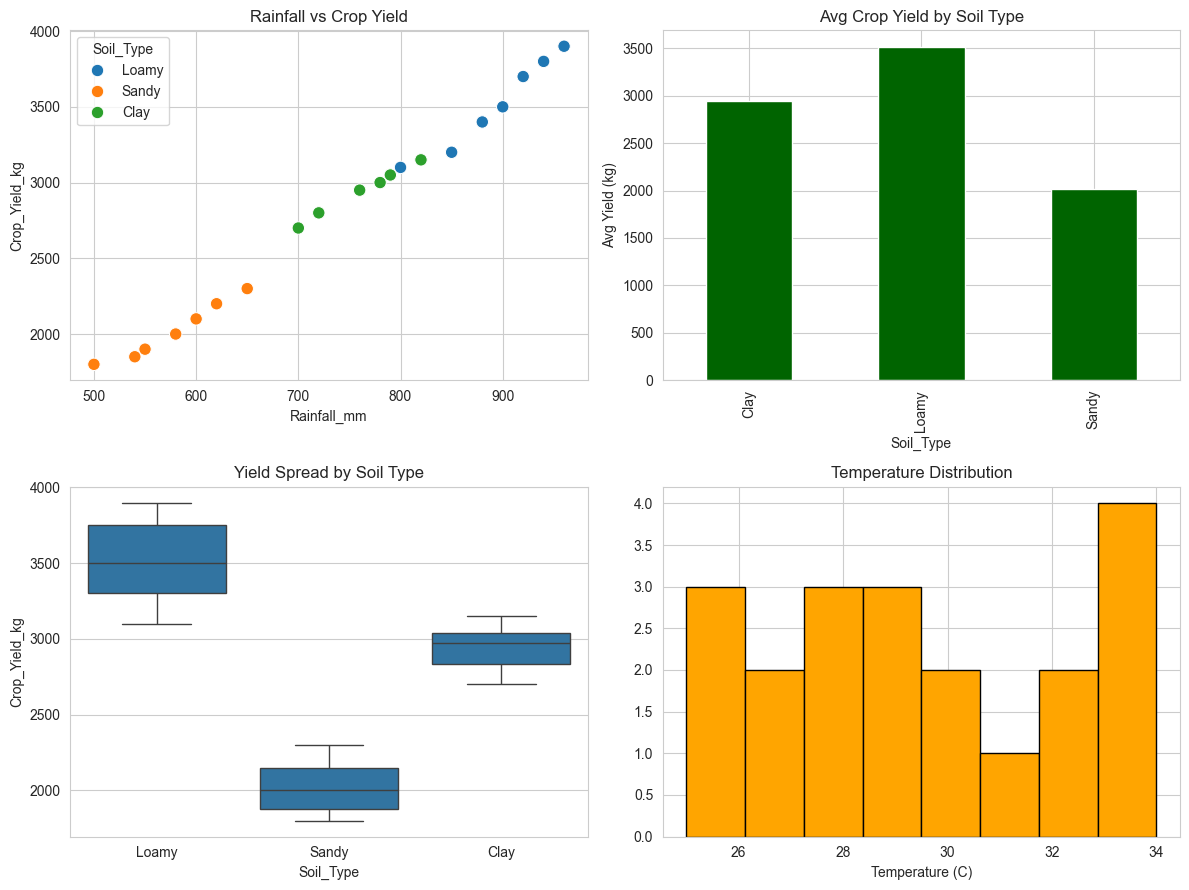

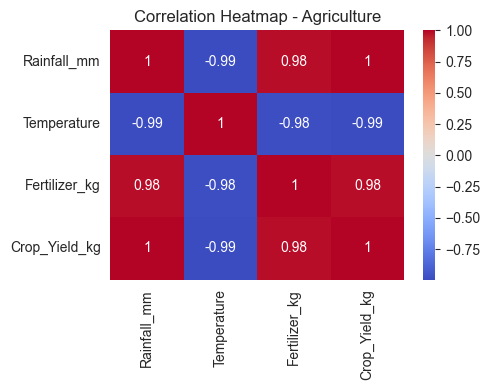

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

#Scatter plot: rainfall vs yield, colored by soil type
sns.scatterplot(data=agri, x='Rainfall_mm', y='Crop_Yield_kg', hue='Soil_Type', ax=axes[0, 0], s=80)
axes[0, 0].set_title('Rainfall vs Crop Yield')

#Bar chart: average yield achieved by each soil type
agri.groupby('Soil_Type')['Crop_Yield_kg'].mean().plot(kind='bar', ax=axes[0, 1], color='darkgreen')
axes[0, 1].set_title('Avg Crop Yield by Soil Type'); axes[0, 1].set_ylabel('Avg Yield (kg)')

#Box plot: yield spread/consistency within each soil type
sns.boxplot(data=agri, x='Soil_Type', y='Crop_Yield_kg', ax=axes[1, 0])
axes[1, 0].set_title('Yield Spread by Soil Type')

#Histogram: temperature distribution across farms
axes[1, 1].hist(agri['Temperature'], bins=8, color='orange', edgecolor='black')
axes[1, 1].set_title('Temperature Distribution'); axes[1, 1].set_xlabel('Temperature (C)')

plt.tight_layout(); plt.savefig('figs/agri_overview.png', dpi=130); plt.show()

#Correlation heatmap: rainfall, temperature, fertilizer vs yield
plt.figure(figsize=(5, 4))
sns.heatmap(agri[['Rainfall_mm', 'Temperature', 'Fertilizer_kg', 'Crop_Yield_kg']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Agriculture')
plt.tight_layout(); plt.savefig('figs/agri_heatmap.png', dpi=130); plt.show()

**Observations:**
1. Rainfall shows a strong positive correlation with crop yield - higher rainfall consistently means higher yield.
2. Loamy soil produces the highest average yield, followed by Clay, then Sandy.
3. Temperature is inversely related to yield - hotter farms (32C+) tend to have the lowest yields, mostly on Sandy soil.
4. Fertilizer usage correlates positively with yield, but less strongly than rainfall.
5. Data cleaning found 0 missing values, 0 duplicates, and 0 IQR outliers.

**Conclusion:** Rainfall and soil type are the leading drivers of crop yield; Sandy soil combined with high temperature and low rainfall marks the highest-risk farming condition.